# Case Study

Pick one audio file from the test set and run all four trained models on it. This loads the saved `.pth` files — nothing gets retrained.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchaudio
import torchaudio.transforms as T

# my models live in two folders, need to add both to the import path
MEL_DIR     = 'deneme'
SINCNET_DIR = 'Project_2'
sys.path.insert(0, MEL_DIR)
sys.path.insert(0, SINCNET_DIR)

from models  import EmotionCNN, SpeakerNet
from sincnet import EmotionSincNet, SpeakerSincNet

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EMOTION_LABELS = ['neutral', 'happy', 'sad', 'angry']
print(f'Device: {device}')

[HAMI-core Msg(773:140065582558528:libvgpu.c:839)]: Initializing.....


Device: cuda


[HAMI-core Msg(773:140065582558528:libvgpu.c:855)]: Initialized


## Pick an audio file

RAVDESS filename: `03-01-EE-II-SS-RR-AA.wav`, where `EE` is the emotion code (01=neutral, 03=happy, 04=sad, 05=angry) and `AA` is the actor (01–24). Going with actor 24 (female, held out as a test speaker), angry.

In [2]:
AUDIO_PATH = os.path.join(MEL_DIR, 'audio_speech_actors_01-24/Actor_24/03-01-05-01-02-02-24.wav')

fname = os.path.basename(AUDIO_PATH).replace('.wav', '')
parts = fname.split('-')
emo_codes = {'01': 'neutral', '03': 'happy', '04': 'sad', '05': 'angry'}
true_emotion = emo_codes[parts[2]]
true_actor   = int(parts[6])

print(f'file:         {fname}')
print(f'true emotion: {true_emotion}')
print(f'true actor:   {true_actor}')

file:         03-01-05-01-02-02-24
true emotion: angry
true actor:   24


## Load audio and prep both inputs

Mel models want a 128-bin log-mel spectrogram, SincNet wants the raw waveform.

In [3]:
# load + downmix + resample
wf, sr = torchaudio.load(AUDIO_PATH)
if wf.shape[0] > 1:
    wf = wf.mean(dim=0, keepdim=True)
if sr != 16000:
    wf = T.Resample(sr, 16000)(wf)

# crop/pad to 3 seconds (same as training)
TARGET = 48000
if wf.shape[1] > TARGET:
    start = (wf.shape[1] - TARGET) // 2
    wf = wf[:, start:start + TARGET]
else:
    wf = torch.nn.functional.pad(wf, (0, TARGET - wf.shape[1]))

# normalise for sincnet
wf_norm = wf / wf.abs().max()

# log-mel for the cnn
mel = T.MelSpectrogram(sample_rate=16000, n_fft=1024, hop_length=512, n_mels=128)(wf)
mel_input = torch.log(mel + 1e-9).unsqueeze(0).to(device)   # (1,1,128,T)
raw_input = wf_norm.unsqueeze(0).to(device)                  # (1,1,48000)

print(f'mel shape: {tuple(mel_input.shape)}')
print(f'raw shape: {tuple(raw_input.shape)}')

mel shape: (1, 1, 128, 94)
raw shape: (1, 1, 48000)


## Visualise

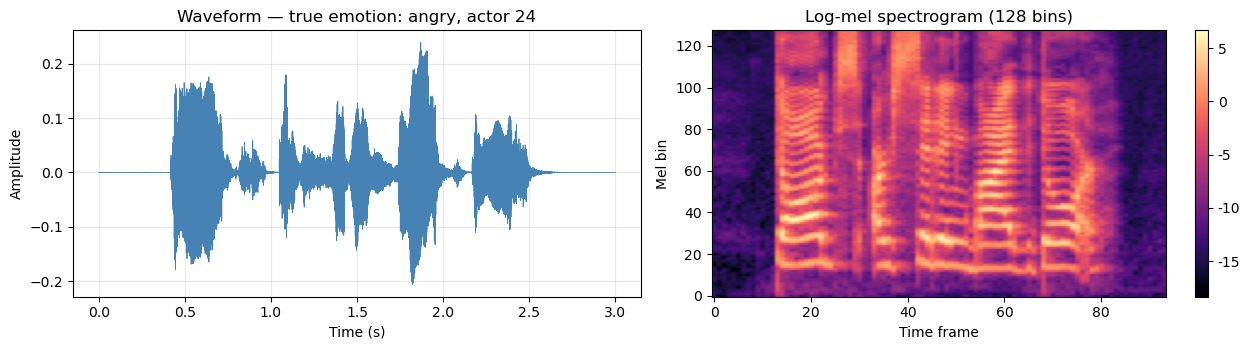

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))

axes[0].plot(np.linspace(0, 3, wf.shape[1]), wf[0].numpy(), color='steelblue', linewidth=0.6)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Waveform — true emotion: {true_emotion}, actor {true_actor}')
axes[0].grid(True, alpha=0.3)

im = axes[1].imshow(mel_input[0, 0].cpu().numpy(), aspect='auto', origin='lower', cmap='magma')
axes[1].set_xlabel('Time frame')
axes[1].set_ylabel('Mel bin')
axes[1].set_title('Log-mel spectrogram (128 bins)')
plt.colorbar(im, ax=axes[1], format='%.0f')

plt.tight_layout()
plt.savefig('case_study_spectrogram.png', dpi=150, bbox_inches='tight')
plt.show()

## Emotion: EmotionCNN vs EmotionSincNet

In [5]:
# load both emotion models
emo_cnn = EmotionCNN(num_emotions=4, dropout_rate=0.1, use_specaugment=False).to(device)
emo_cnn.load_state_dict(torch.load(os.path.join(MEL_DIR, 'emotion_cnn_best.pth'), map_location=device))
emo_cnn.eval()

emo_sin = EmotionSincNet(num_emotions=4, fc_hidden=256, dropout_rate=0.2).to(device)
emo_sin.load_state_dict(torch.load(os.path.join(SINCNET_DIR, 'emotion_sincnet_best.pth'), map_location=device))
emo_sin.eval()

with torch.no_grad():
    cnn_probs = torch.softmax(emo_cnn(mel_input), dim=1)[0].cpu().numpy()
    sin_probs = torch.softmax(emo_sin(raw_input), dim=1)[0].cpu().numpy()

cnn_pred = EMOTION_LABELS[cnn_probs.argmax()]
sin_pred = EMOTION_LABELS[sin_probs.argmax()]

print(f'true emotion: {true_emotion}\n')
print(f'{"":10s}{"EmotionCNN":>14s}{"EmotionSincNet":>18s}')
print('-' * 42)
for i, lab in enumerate(EMOTION_LABELS):
    print(f'{lab:10s}{cnn_probs[i]*100:13.1f}%{sin_probs[i]*100:17.1f}%')
print()
print(f'EmotionCNN     -> {cnn_pred} ({"correct" if cnn_pred == true_emotion else "wrong"})')
print(f'EmotionSincNet -> {sin_pred} ({"correct" if sin_pred == true_emotion else "wrong"})')

true emotion: angry

              EmotionCNN    EmotionSincNet
------------------------------------------
neutral             5.6%              0.8%
happy              34.9%             46.3%
sad                13.9%             20.8%
angry              45.6%             32.1%

EmotionCNN     -> angry (correct)
EmotionSincNet -> happy (wrong)


## Speaker: SpeakerNet vs SpeakerSincNet

In [6]:
spk_net = SpeakerNet(n_mels=128, num_speakers=24, lstm_hidden=128, lstm_layers=1, dropout_rate=0.1).to(device)
spk_net.load_state_dict(torch.load(os.path.join(MEL_DIR, 'speaker_net_best.pth'), map_location=device))
spk_net.eval()

spk_sin = SpeakerSincNet(num_speakers=24, fc_hidden=512, dropout_rate=0.2).to(device)
spk_sin.load_state_dict(torch.load(os.path.join(SINCNET_DIR, 'speaker_sincnet_best.pth'), map_location=device))
spk_sin.eval()

with torch.no_grad():
    net_probs = torch.softmax(spk_net(mel_input), dim=1)[0].cpu().numpy()
    sin_probs = torch.softmax(spk_sin(raw_input), dim=1)[0].cpu().numpy()

net_pred = int(net_probs.argmax()) + 1
sin_pred = int(sin_probs.argmax()) + 1

# top-3 from each
print(f'true actor: {true_actor}\n')
for name, probs in [('SpeakerNet', net_probs), ('SpeakerSincNet', sin_probs)]:
    top = np.argsort(-probs)[:3]
    line = '  '.join(f'actor {i+1:2d} ({probs[i]*100:.1f}%)' for i in top)
    print(f'{name:14s} top-3: {line}')

print()
print(f'SpeakerNet     -> actor {net_pred} ({"correct" if net_pred == true_actor else "wrong"})')
print(f'SpeakerSincNet -> actor {sin_pred} ({"correct" if sin_pred == true_actor else "wrong"})')

true actor: 24

SpeakerNet     top-3: actor 24 (97.4%)  actor 16 (0.8%)  actor  6 (0.8%)
SpeakerSincNet top-3: actor 24 (100.0%)  actor  6 (0.0%)  actor 12 (0.0%)

SpeakerNet     -> actor 24 (correct)
SpeakerSincNet -> actor 24 (correct)


## Save summary + audio for the submission

In [7]:
import shutil

# need these from the previous cells - re-grabbing for clarity
mel_emo_pred = EMOTION_LABELS[torch.softmax(emo_cnn(mel_input), dim=1)[0].argmax().item()]
sin_emo_pred = EMOTION_LABELS[torch.softmax(emo_sin(raw_input), dim=1)[0].argmax().item()]
mel_spk_pred = int(torch.softmax(spk_net(mel_input), dim=1)[0].argmax().item()) + 1
sin_spk_pred = int(torch.softmax(spk_sin(raw_input), dim=1)[0].argmax().item()) + 1

ok = lambda b: 'correct' if b else 'wrong'
summary = pd.DataFrame([
    ('file',                fname),
    ('true emotion',        true_emotion),
    ('true actor',          f'actor {true_actor}'),
    ('EmotionCNN',          f'{mel_emo_pred} ({ok(mel_emo_pred == true_emotion)})'),
    ('EmotionSincNet',      f'{sin_emo_pred} ({ok(sin_emo_pred == true_emotion)})'),
    ('SpeakerNet',          f'actor {mel_spk_pred} ({ok(mel_spk_pred == true_actor)})'),
    ('SpeakerSincNet',      f'actor {sin_spk_pred} ({ok(sin_spk_pred == true_actor)})'),
], columns=['property', 'value'])

summary.to_csv('case_study_summary.csv', index=False)
print(summary.to_string(index=False))

# also copy the audio file for the submission zip
shutil.copy(AUDIO_PATH, 'case_study_audio.wav')

      property                value
          file 03-01-05-01-02-02-24
  true emotion                angry
    true actor             actor 24
    EmotionCNN      angry (correct)
EmotionSincNet        happy (wrong)
    SpeakerNet   actor 24 (correct)
SpeakerSincNet   actor 24 (correct)


'case_study_audio.wav'